# IntroML2026 Final Project : Predicting Nuclear Waste Temperature

**Group name :** Bétonbraisé

**Authors:** Alice Verniquet and Laura Monney


# 1. Introduction

<div style="text-align: justify;">
This project aims to predict the temperature evolution around nuclear waste canisters 
using measurements from approximately 300 sensors and known heating power values. 
The data spans three different experimental modes, each with distinct heating profiles. 
Our goal is to build a machine learning model that can generalize to unseen sensor 
locations, potentially replacing computationally expensive methods such as finite element simulations.
</div>

# 2. Imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.spatial import KDTree
from typing import Optional, Tuple, List
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"

#data loading
train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)
print(test.columns.tolist())

['sensor', 'time', 'power']


# 3. Data exploration

In [2]:
#displaying the first rows of the dataframes
sensors.head()

,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0


In [3]:
#inspecting the dataframes
print(train.info())
print(sensors.shape)
print(test.shape)

<class 'pandas.DataFrame'>
RangeIndex: 6626928 entries, 0 to 6626927
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   sensor       category
 1   time         float64 
 2   power        float32 
 3   temperature  float32 
dtypes: category(1), float32(2), float64(1)
memory usage: 113.8 MB
None
(325, 4)
(2190480, 3)


In [4]:
#Statistics
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [5]:
#detecting missing values
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [6]:
#finding the number of the two sensors which are very far from our expected values; outliers
neg_outlier = train[train['temperature'] == train['temperature'].min()]
pos_outlier = train[train['temperature'] == train['temperature'].max()]
print(neg_outlier['sensor'], pos_outlier['sensor'])

483784     N277
483785     N277
483786     N277
483787     N277
483788     N277
           ... 
4910859    N277
4910860    N277
4910861    N277
4910862    N277
4910863    N277
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96'] 2181592    N927
2181593    N927
2181594    N927
2181595    N927
2181596    N927
           ... 
6608667    N927
6608668    N927
6608669    N927
6608670    N927
6608671    N927
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96']


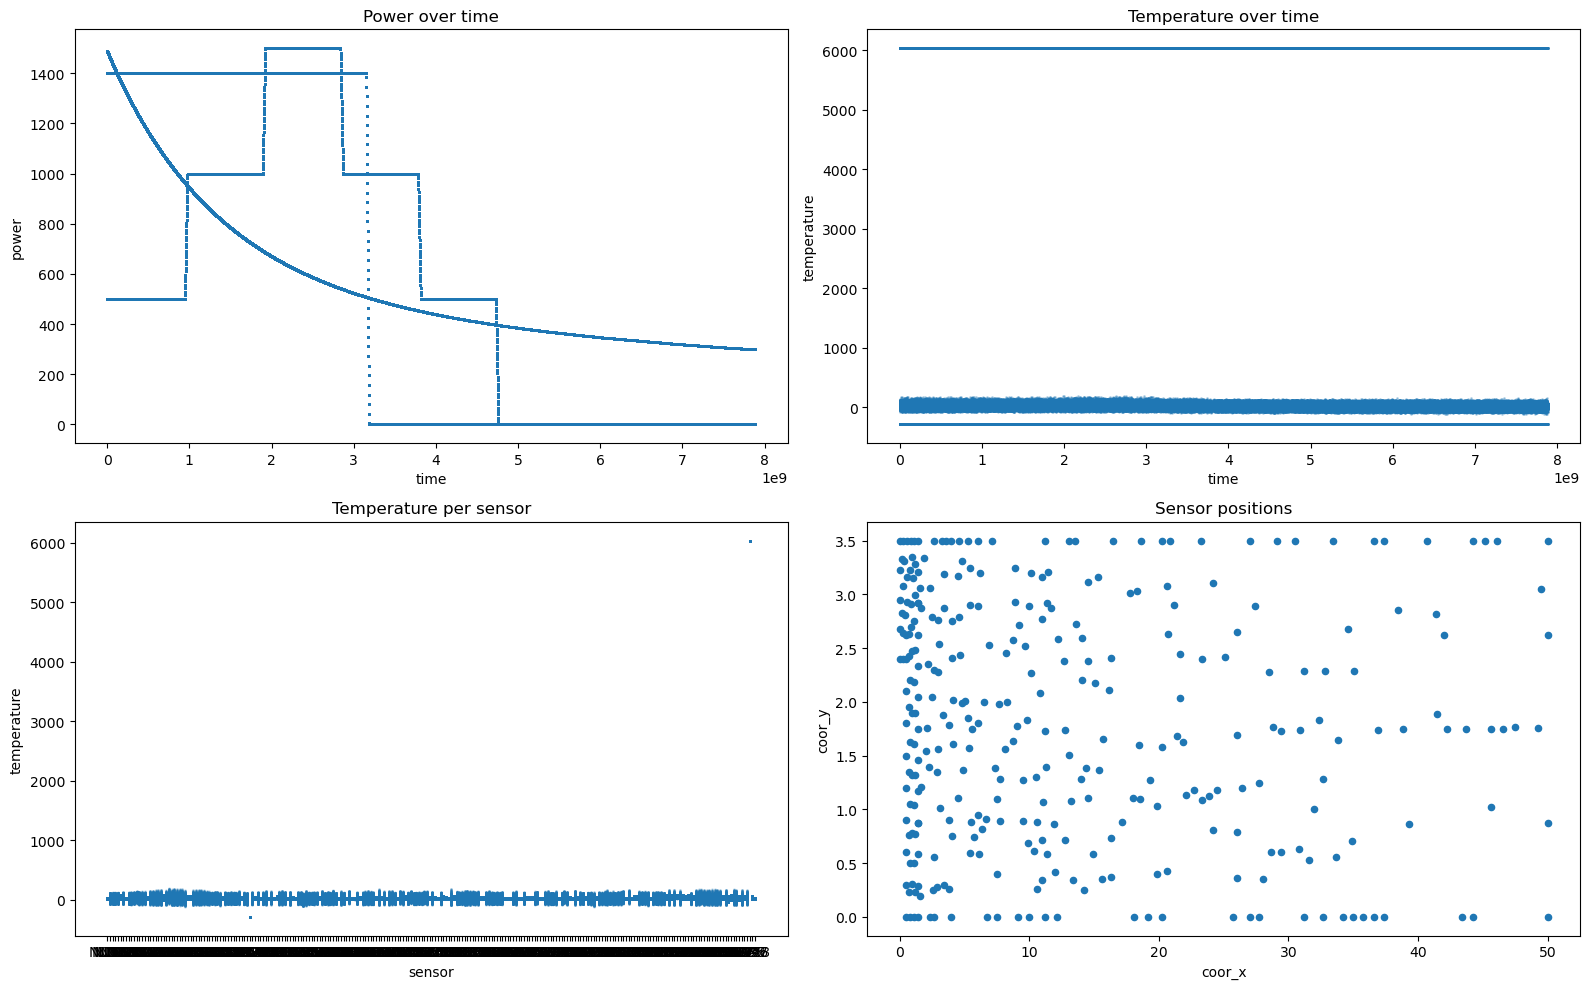

In [7]:
#visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

train.plot(kind='scatter', x='time', y='power', ax=axes[0,0], title='Power over time', s=1)
train.plot(kind='scatter', x='time', y='temperature', alpha=0.3, ax=axes[0,1], title='Temperature over time', s=1)
train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15, ax=axes[1,0], title='Temperature per sensor', s=1)
sensors.plot(kind='scatter', x='coor_x', y='coor_y', ax=axes[1,1], title='Sensor positions')

plt.tight_layout()
plt.show()

### Key Observations

<div style="text-align: justify;">
Through the exploratory data analysis, we identified several important characteristics 
of the dataset that will guide our preprocessing steps :

- **Missing values :** 99403 temperature values are missing across multiple sensors 
and will need to be imputed before training.

- **Outlier sensors :** Two sensors (N277 and N927) show clearly aberrant temperature 
values (below -292°C and above 6039°C) and will be removed entirely.

- **3 experimental modes :** The power-time plot reveals 3 distinct heating profiles, 
suggesting the data contains 3 separate experiments that should be treated independently.

- **Sensor positions :** The sensors are not evenly distributed in space, 
which means a simple global average would be biased when imputing missing values.

- **Temperature range :** Most sensors record temperatures between 14°C and 30°C, 
with a few reaching higher values close to the canister.
</div>

# 4. Preprocessing

## 4.1 Missing values

<div style="text-align: justify;">
We use linear interpolation grouped by sensor because the data is ordered 
chronologically. This preserves the temporal evolution of each sensor better 
than a global mean, which would ignore the time structure.
</div>

In [8]:
#list of the missing values
missing_idx = train[train['temperature'].isna()].index
print(missing_idx)
print(len(missing_idx))

Index([    106,     364,     477,     501,     568,     657,     712,     769,
           833,     870,
       ...
       6626263, 6626302, 6626312, 6626504, 6626575, 6626627, 6626671, 6626726,
       6626890, 6626924],
      dtype='int64', length=99403)
99403


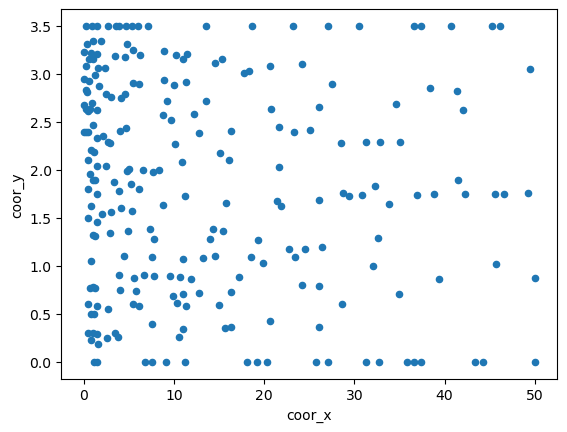

In [9]:
#see where the missing values are --> a bit everywhere
sensors_misval = train.loc[missing_idx, 'sensor'].unique()
sensors_misval_coords = sensors[sensors['sensor'].isin(sensors_misval)]

sensors_misval_coords.plot(kind='scatter', x='coor_x', y='coor_y')
plt.show()

In [10]:
#fills the missing temperature by using interpolate because our data is ordered chronologically 
#and taking into account ouly values from the same sensor
train['temperature'] = (
    train.groupby('sensor')['temperature']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

In [11]:
#control that every missing values are replaced
train.isna().any() 

sensor         False
time           False
power          False
temperature    False
dtype: bool

## 4.2 Remove outliers

In [12]:
#get rid of the outlier sensors
train = train[train["sensor"] != "N277"]
train = train[train["sensor"] != "N927"]
sensors = sensors[sensors["sensor"] != "N277"]
sensors = sensors[sensors["sensor"] != "N927"]

In [13]:
#verify that the outlier sensors are gone
np.all(train["sensor"] != 'N277') and np.all(train["sensor"] != 'N927')

np.True_

In [14]:
#on teste d'enlever encore 2 outliers en plus pour voir si ça améliore les résultats du modèle
for sensor in ['N204', 'N196']:
    train = train[train['sensor'] != sensor]
    sensors = sensors[sensors['sensor'] != sensor]
    
print(f"Capteurs défectueux supprimés !")
print(f"Taille train : {len(train)}")

Capteurs défectueux supprimés !
Taille train : 6517392


In [15]:
#control if values are reasonable
print("Min température:", train['temperature'].min())
print("Max température:", train['temperature'].max())
print("Mean température:", train['temperature'].mean())

Min température: -117.59514
Max température: 179.88826
Mean température: 23.086359


<Axes: xlabel='sensor', ylabel='temperature'>

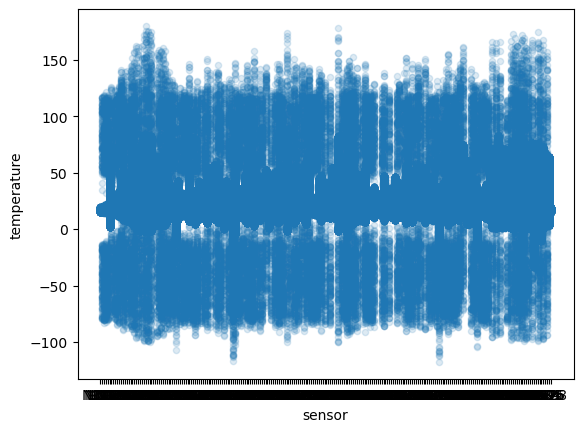

In [16]:
#Visualization after getting rid of 4 bad sensors
train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15)

## Filtre global

In [17]:
# Filtre global sur les températures physiquement impossibles
before = len(train)
train = train[(train['temperature'] >= -30) & (train['temperature'] <= 190)]
after = len(train)
print(f"Lignes supprimées : {before - after} ({(before-after)/before*100:.2f}%)")

Lignes supprimées : 14397 (0.22%)


## 4.3 Merge coordinates with the training data

In [18]:
#we see there are duplicates in sensors
print(sensors['sensor'].duplicated().sum())  # y a-t-il des doublons ?
print(sensors.shape)
print(sensors['sensor'].nunique())

2
(321, 4)
319


In [19]:
#drop duplicates
sensors_unique = sensors.drop_duplicates(subset='sensor')

In [20]:
# merge the train dataframe with the sensors dataframe to get the coordinates of each sensor
train = train.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
#drop the coor_z column because it is not useful for our model and it is highly correlated with coor_x and coor_y
train = train.drop(columns=['coor_z'])

# merge the test dataframe with the sensors dataframe to get the coordinates of each sensor
test = test.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
#drop the coor_z column because it is not useful for our model and it is highly correlated with coor_x and coor_y
test = test.drop(columns=['coor_z'])

# control
print(train.columns)

Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y'], dtype='str')


## 4.4 Normalisation

<div style="text-align: justify;">
We normalize time and power using StandardScaler because their scales differ 
greatly (billions vs 0-1500). This ensures that no feature dominates the model 
simply due to its magnitude.
</div>

In [21]:
# ajout de features
train['dist_r'] = np.sqrt(train['coor_x']**2 + train['coor_y']**2)

test['dist_r'] = np.sqrt(test['coor_x']**2 + test['coor_y']**2)

In [22]:
# Normalisation
features = ['time', 'power', 'coor_x', 'coor_y', 'dist_r']

scaler = StandardScaler()
train[features] = scaler.fit_transform(train[features])
test[features]  = scaler.transform(test[features])

print(train[features].describe())

               time         power        coor_x        coor_y        dist_r
count  6.502995e+06  6.502995e+06  6.502995e+06  6.502995e+06  6.502995e+06
mean  -6.153744e-18  1.079702e-16 -3.356588e-17  1.029354e-16  7.384493e-17
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -1.731678e+00 -1.055908e+00 -1.003078e+00 -1.685280e+00 -1.017777e+00
25%   -8.659358e-01 -1.055908e+00 -8.321786e-01 -8.806449e-01 -8.122364e-01
50%   -1.934200e-04 -2.095690e-01 -3.496426e-01  1.133791e-03 -3.690630e-01
75%    8.659666e-01  8.456152e-01  6.008313e-01  8.880432e-01  5.818857e-01
max    1.732886e+00  1.796377e+00  2.660440e+00  1.508282e+00  2.700238e+00


## 4.5 Separation of modes

<div style="text-align: justify;">
The power-time plot reveals 3 distinct experimental modes. Since each sensor has 
27384 timesteps split into 3 equal blocks of 9128, we separate them by dividing 
the dataset into 3 equal parts of 2190720 rows each.
</div>

(2167665, 7) (2167665, 7) (2167665, 7)


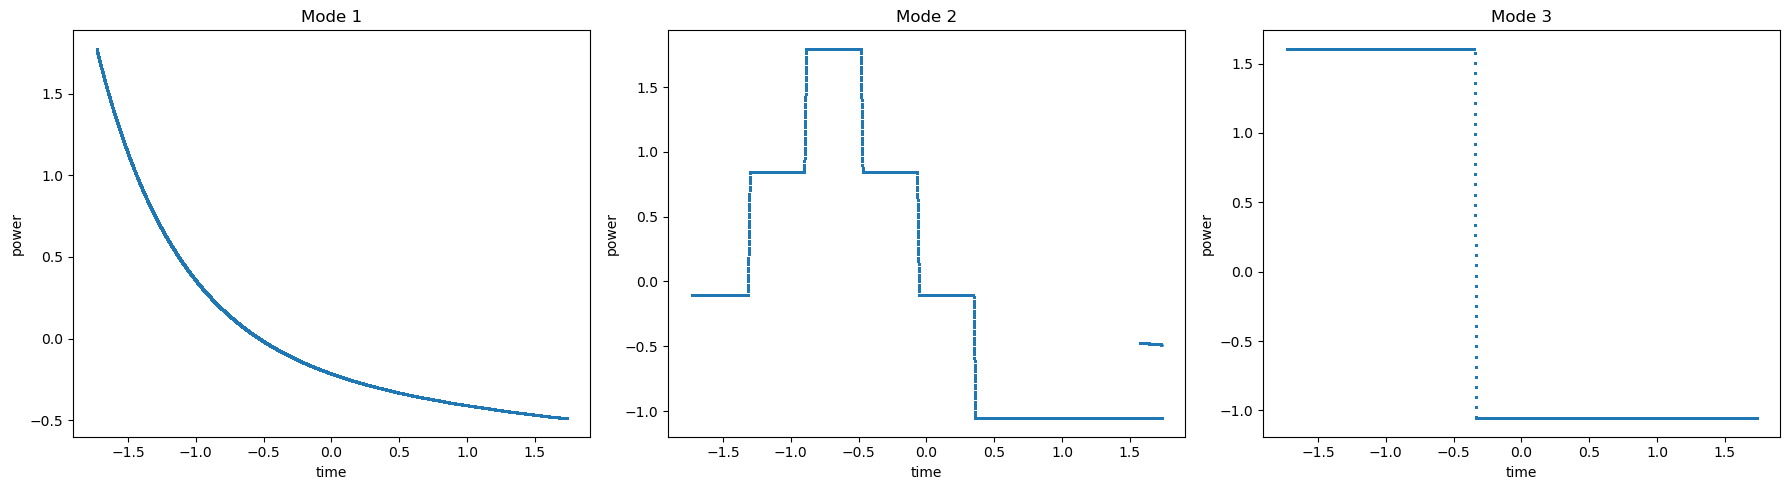

In [23]:
#separate out three modes so that we can try different models for different modes
BLOCK = len(train) // 3

mode1 = train.iloc[0       : BLOCK].copy()
mode2 = train.iloc[BLOCK   : 2*BLOCK].copy()
mode3 = train.iloc[2*BLOCK :].copy()

# Control
print(mode1.shape, mode2.shape, mode3.shape)

# Visualization of the three modes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

(730160, 6) (730160, 6) (730160, 6)


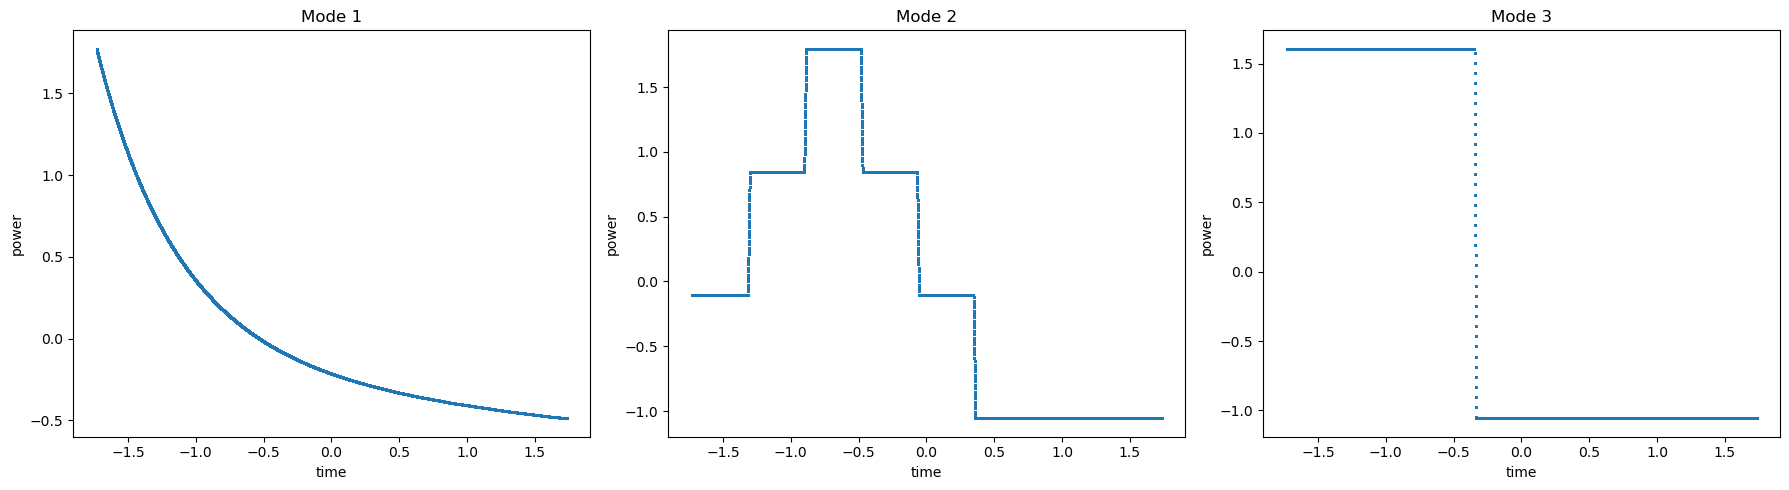

In [24]:
#same for test
BLOCK = len(test) // 3

test_mode1 = test.iloc[0       : BLOCK].copy()
test_mode2 = test.iloc[BLOCK   : 2*BLOCK].copy()
test_mode3 = test.iloc[2*BLOCK :].copy()

# Vérification
print(test_mode1.shape, test_mode2.shape, test_mode3.shape)

# Visualiser les 3 modes séparément
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

test_mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
test_mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
test_mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

## 4.5 Outliers

In [25]:
random_sensor = train['sensor'].sample(1).values[0]
subset = train[train['sensor'] == random_sensor]
print(f"Sensor: {random_sensor}, shape: {subset.shape}")
print(subset.head())

Sensor: N212, shape: (27303, 7)
       sensor      time     power  temperature  coor_x    coor_y   dist_r
300614   N212 -1.731678  1.773492    97.842194 -0.9005  0.709892 -0.85078
300615   N212 -1.731298  1.772206    23.013815 -0.9005  0.709892 -0.85078
300616   N212 -1.730919  1.770921    29.310492 -0.9005  0.709892 -0.85078
300617   N212 -1.730539  1.769636    33.207611 -0.9005  0.709892 -0.85078
300618   N212 -1.730159  1.768350    34.419621 -0.9005  0.709892 -0.85078


<Axes: xlabel='time', ylabel='temperature'>

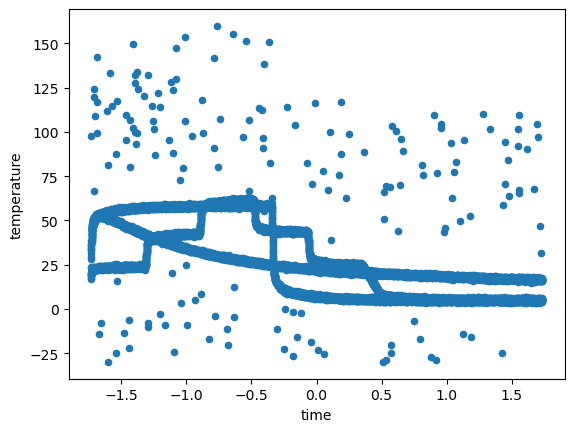

In [26]:
subset.plot(kind='scatter', x='time', y='temperature')

Before: 27303, After: 27220, Removed: 83


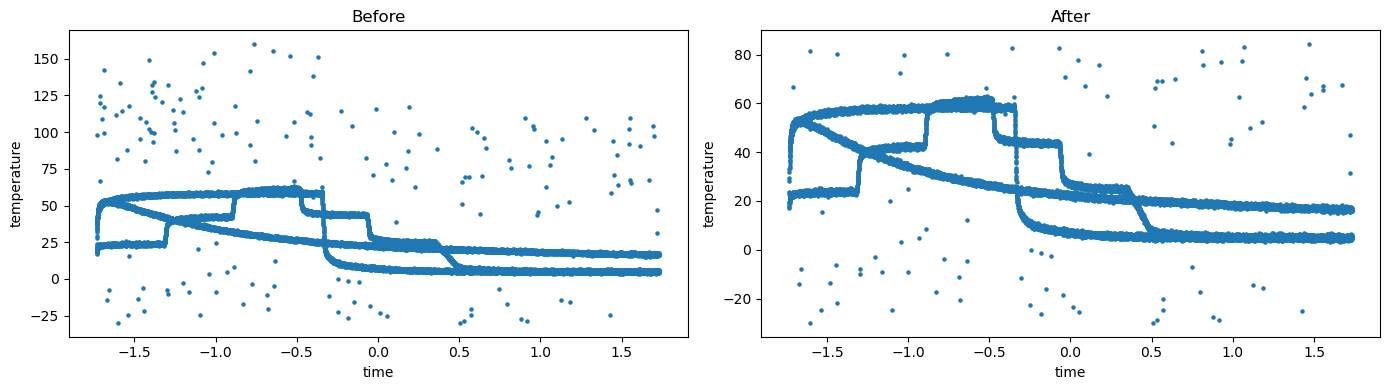

In [27]:
subset_clean = subset[np.abs(stats.zscore(subset['temperature'])) < 3]

print(f"Before: {len(subset)}, After: {len(subset_clean)}, Removed: {len(subset) - len(subset_clean)}")

# Plot to compare
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
subset.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Before', s=5)
subset_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='After', s=5)
plt.tight_layout()
plt.show()

In [28]:
def replace_outliers_mode1(df, threshold=3, column='temperature'):
    time = df['time'].to_numpy()
    temp = df[column].to_numpy()
    
    degree = 4
    coeffs = np.polyfit(time, temp, degree)
    trend = np.polyval(coeffs, time)
    
    residuals = temp - trend
    outlier_mask = np.abs(stats.zscore(residuals)) >= threshold
    
    temp_replaced = temp.copy()
    temp_replaced[outlier_mask] = trend[outlier_mask]  # Replace with polynomial trend value
    
    df = df.copy()
    df[column] = temp_replaced
    return df


def replace_outliers_mode2(df, threshold=3, column='temperature'):
    power_levels = pd.cut(df['power'], bins=8)
    
    def replace_group(x):
        if len(x) > 1:
            outlier_mask = np.abs(stats.zscore(x, ddof=0)) >= threshold
            x = x.copy()
            x[outlier_mask] = x[~outlier_mask].mean()  # Replace with group mean
        return x
    
    df = df.copy()
    df[column] = df.groupby(power_levels, observed=True)[column].transform(replace_group)
    return df


def replace_outliers_mode3(df, threshold=3, column='temperature'):
    power_levels = pd.cut(df['power'], bins=2)
    
    def replace_group(x):
        if len(x) > 1:
            outlier_mask = np.abs(stats.zscore(x, ddof=0)) >= threshold
            x = x.copy()
            x[outlier_mask] = x[~outlier_mask].mean()  # Replace with group mean
        return x
    
    df = df.copy()
    df[column] = df.groupby(power_levels, observed=True)[column].transform(replace_group)
    return df


OUTLIER_FN = {
    1: replace_outliers_mode1,
    2: replace_outliers_mode2,
    3: replace_outliers_mode3,
}


def clean_mode(mode_df, sensors_unique, mode_id, threshold=3):
    outlier_fn = OUTLIER_FN[mode_id]
    
    return (
        mode_df.merge(sensors_unique, on='sensor')
        .drop(columns=['coor_x_y', 'coor_y_y', 'coor_z'])
        .rename(columns={'coor_x_x': 'coor_x', 'coor_y_x': 'coor_y'})
        .groupby(['sensor', pd.qcut(range(len(mode_df)), q=3, labels=['t1', 't2', 't3'])])
        .apply(lambda df: outlier_fn(df, threshold), include_groups=False)
        .reset_index(level=[0, 1], drop=True)
        .reset_index()
        .rename(columns={'index': 'sensor'})
    )

mode1_clean = clean_mode(mode1, sensors_unique, mode_id=1)
mode2_clean = clean_mode(mode2, sensors_unique, mode_id=2)
mode3_clean = clean_mode(mode3, sensors_unique, mode_id=3)

train_clean = pd.concat([mode1_clean, mode2_clean, mode3_clean], ignore_index=True)

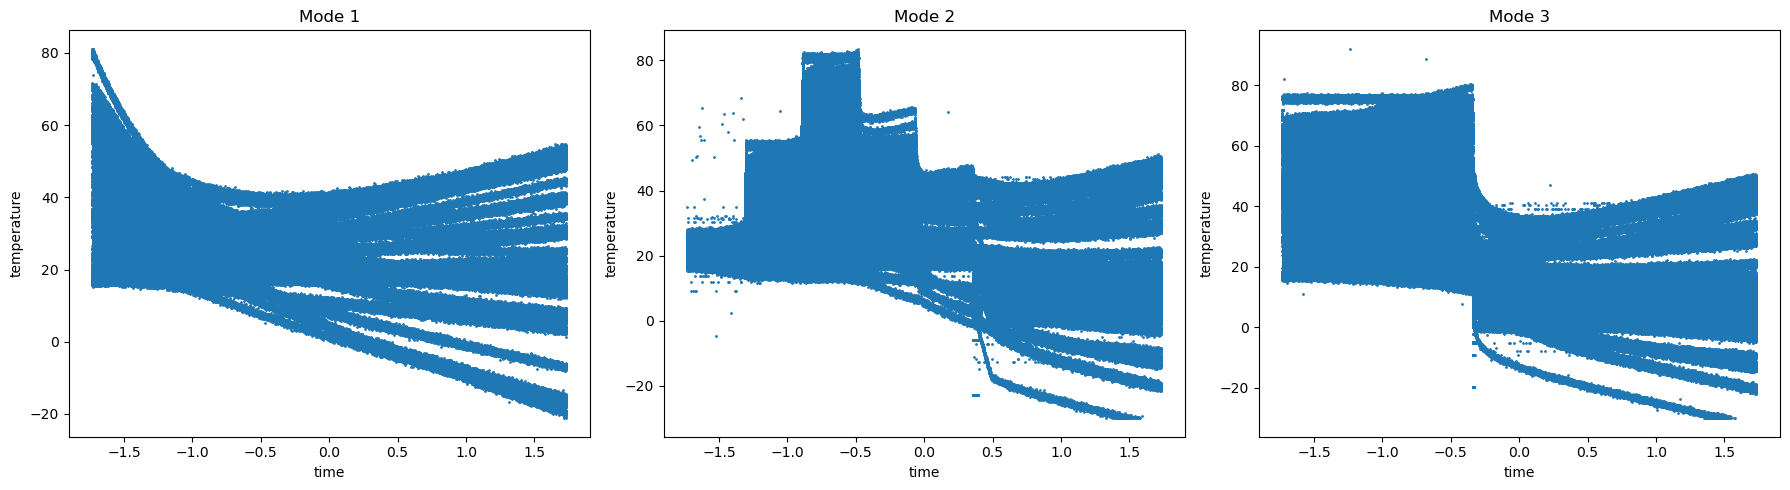

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Mode 1', s=1)
mode2_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='Mode 2', s=1)
mode3_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

# 5. Model Training

blablabla c'est ici qu'on teste plusieurs modèles, voilàààààà

## 5.1 Linear regression

résultat sur le learderboard : 7.87198 sans le drift, le filtre général et l'enlèvement des 2 outliers supplémentaires

In [ ]:
from sklearn.model_selection import train_test_split

# Définir les features et la target manuellement
features = ['time', 'power', 'coor_x', 'coor_y']
target = 'temperature'

X = train[features].values
y = train[target].values

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (5184743, 4)
X_test shape: (1296186, 4)


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Créer et entraîner le modèle
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prédictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

# Evaluer avec RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Test:  {rmse_test:.4f}")

RMSE Train: 10.2977
RMSE Test:  10.3047


In [34]:
# Normalisation de test avec les mêmes scalers que le train
#test[['time', 'power']] = scaler.transform(test[['time', 'power']])
#test[['coor_x', 'coor_y']] = scaler_coords.transform(test[['coor_x', 'coor_y']])

#print("test après normalisation:")
#print(test[['time', 'power', 'coor_x', 'coor_y']].describe())

In [35]:
# Prédictions sur le vrai test set
#X_kaggle = test[['time', 'power', 'coor_x', 'coor_y']].values
#y_pred = lr_model.predict(X_kaggle)

#print(f"Prédictions générées : {len(y_pred)} lignes")
#print(y_pred[:10])
#print(y_pred.min(), y_pred.max())

# 5.2 NN

score sur le leaderbord : 3.2

In [30]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")

# Définition du MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.network(x)


Device utilisé : cpu


In [31]:
from sklearn.model_selection import train_test_split
def train_mlp(X_train, y_train, X_val, y_val, n_epochs=30):
    """Entraîne un MLP sur un mode donné et retourne le modèle entraîné."""
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=4096, shuffle=True)
    
    model = MLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()
    
    best_rmse = float('inf')
    best_model_state = None
    
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            rmse = torch.sqrt(criterion(model(X_val_t), y_val_t)).item()
        
        scheduler.step(rmse)
        
        # Early stopping : on sauvegarde le meilleur modèle
        if rmse < best_rmse:
            best_rmse = rmse
            best_model_state = model.state_dict().copy()
        
        print(f"Epoch {epoch+1}/{n_epochs} | RMSE Val: {rmse:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    # On recharge le meilleur modèle
    model.load_state_dict(best_model_state)
    print(f"Meilleur RMSE Val: {best_rmse:.4f}")
    return model

# Séparer train en 3 modes
BLOCK = len(train_clean) // 3
mode1 = train_clean.iloc[0      : BLOCK].copy()
mode2 = train_clean.iloc[BLOCK  : 2*BLOCK].copy()
mode3 = train_clean.iloc[2*BLOCK:].copy()

features = ['time', 'power', 'coor_x', 'coor_y', 'dist_r']
target = 'temperature'

# Entraîner un modèle par mode
print("=== MODE 1 ===")
X1 = mode1[features].values
y1 = mode1[target].values
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, train_size=0.8, random_state=42)
model1 = train_mlp(X1_train, y1_train, X1_val, y1_val)

print("=== MODE 2 ===")
X2 = mode2[features].values
y2 = mode2[target].values
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, train_size=0.8, random_state=42)
model2 = train_mlp(X2_train, y2_train, X2_val, y2_val)

print("=== MODE 3 ===")
X3 = mode3[features].values
y3 = mode3[target].values
X3_train, X3_val, y3_train, y3_val = train_test_split(X3, y3, train_size=0.8, random_state=42)
model3 = train_mlp(X3_train, y3_train, X3_val, y3_val)

=== MODE 1 ===
Epoch 1/30 | RMSE Val: 5.6733 | LR: 1.00e-03
Epoch 2/30 | RMSE Val: 5.2707 | LR: 1.00e-03
Epoch 3/30 | RMSE Val: 5.1505 | LR: 1.00e-03
Epoch 4/30 | RMSE Val: 5.0610 | LR: 1.00e-03
Epoch 5/30 | RMSE Val: 4.8943 | LR: 1.00e-03
Epoch 6/30 | RMSE Val: 4.8141 | LR: 1.00e-03
Epoch 7/30 | RMSE Val: 4.7227 | LR: 1.00e-03
Epoch 8/30 | RMSE Val: 4.6901 | LR: 1.00e-03
Epoch 9/30 | RMSE Val: 4.6420 | LR: 1.00e-03
Epoch 10/30 | RMSE Val: 4.4228 | LR: 1.00e-03
Epoch 11/30 | RMSE Val: 4.3113 | LR: 1.00e-03
Epoch 12/30 | RMSE Val: 4.1668 | LR: 1.00e-03
Epoch 13/30 | RMSE Val: 4.1500 | LR: 1.00e-03
Epoch 14/30 | RMSE Val: 3.9049 | LR: 1.00e-03
Epoch 15/30 | RMSE Val: 3.7313 | LR: 1.00e-03
Epoch 16/30 | RMSE Val: 3.6346 | LR: 1.00e-03
Epoch 17/30 | RMSE Val: 3.4358 | LR: 1.00e-03
Epoch 18/30 | RMSE Val: 3.2816 | LR: 1.00e-03
Epoch 19/30 | RMSE Val: 3.2852 | LR: 1.00e-03
Epoch 20/30 | RMSE Val: 3.1905 | LR: 1.00e-03
Epoch 21/30 | RMSE Val: 2.9954 | LR: 1.00e-03
Epoch 22/30 | RMSE Val: 3.08

In [32]:
# Séparer test en 3 modes
BLOCK_test = len(test) // 3
test1 = test.iloc[0           : BLOCK_test].copy()
test2 = test.iloc[BLOCK_test  : 2*BLOCK_test].copy()
test3 = test.iloc[2*BLOCK_test:].copy()

def predict_mlp(model, test_df, features):
    """Prédit les températures avec un MLP."""
    model.eval()
    X = torch.tensor(test_df[features].values, dtype=torch.float32).to(device)
    with torch.no_grad():
        return model(X).cpu().numpy().flatten()

y_pred1 = predict_mlp(model1, test1, features)
y_pred2 = predict_mlp(model2, test2, features)
y_pred3 = predict_mlp(model3, test3, features)

y_pred = np.concatenate([y_pred1, y_pred2, y_pred3])
print(f"Prédictions totales : {len(y_pred)}")
print(f"Min: {y_pred.min():.2f}, Max: {y_pred.max():.2f}")

Prédictions totales : 2190480
Min: -21.41, Max: 75.09


## 5.3 KNN

In [77]:
#Transforms data into numpy arrays and splits it into a train, val and test set
def preprocess_data(
    df: pd.DataFrame,
    label: str,
    train_size: float = 0.6,
    val_size: float = 0.2,
    seed: Optional[int] = None,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    List[str],
]:
    df = df.sample(frac=1, random_state=seed)

    train, val, test = (
        df[: int(len(df) * train_size)],
        df[int(len(df) * train_size) : int(len(df) * (train_size + val_size))],
        df[int(len(df) * (train_size + val_size)) :],
    )

    X_train = train.drop(columns=label).to_numpy()
    X_val = val.drop(columns=label).to_numpy()
    X_test = test.drop(columns=label).to_numpy()

    y_train = train[label].to_numpy()
    y_val = val[label].to_numpy()
    y_test = test[label].to_numpy()

    return X_train, y_train, X_val, y_val, X_test, y_test

In [78]:
def predict(
    samples: np.ndarray, 
    X: np.ndarray,
    y: np.ndarray,
    k: int = 1):

    #find indices of k neighbors
    tree = KDTree(X)                    
    _, indices = tree.query(samples, k=k, workers=-1)
    
    if k == 1:
        return y[indices].flatten()
    return np.mean(y[indices], axis=1)

In [79]:
def rmse(
    labels_gt: np.ndarray,
    labels_pred: np.ndarray):

    rmse = np.sqrt(np.mean((labels_gt - labels_pred) ** 2))

    return rmse

In [80]:
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(df=train_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)

In [81]:
y_pred_train = predict(X_val, X_train, y_train, k=25)

In [82]:
#rmse for the prediction without sepatating our data by their powers
print(rmse(y_val, y_pred_train))

8.011978


In [83]:
X_train1, y_train1, X_val1, y_val1, X_test1, y_test1 = preprocess_data(df=mode1_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)
X_train2, y_train2, X_val2, y_val2, X_test2, y_test2 = preprocess_data(df=mode2_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)
X_train3, y_train3, X_val3, y_val3, X_test3, y_test3 = preprocess_data(df=mode3_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)

In [91]:
y_pred_mode1 = predict(X_test1, X_train1, y_train1, k=4)
y_pred_mode2 = predict(X_test2, X_train2, y_train2, k=4)
y_pred_mode3 = predict(X_test3, X_train3, y_train3, k=4)

y_test_modes = np.concatenate([y_test1, y_test2, y_test3])
y_pred_modes = np.concatenate([y_pred_mode1, y_pred_mode2, y_pred_mode3])

In [92]:
print(rmse(y_test1, y_pred_mode1))
print(rmse(y_test2, y_pred_mode2))
print(rmse(y_test3, y_pred_mode3))

0.6018902
0.66343445
0.8340836


In [86]:
print(rmse(y_test_modes, y_pred_modes))

0.7207047


In [89]:
#trouver meilleur k
k_values = []
accs = []
for i in range(1, 10):
    acc = rmse(y_val1, predict(X_val1, X_train1, y_train1, k=i))
    k_values.append(i)
    accs.append(acc)

C:\Users\alice\AppData\Local\Temp\ipykernel_4348\1202109312.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


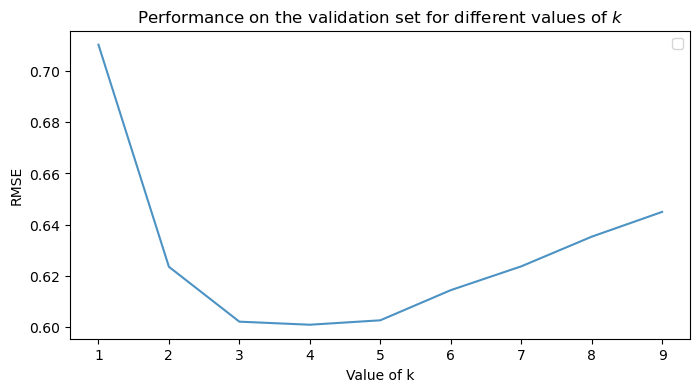

In [90]:
# Plot rmse in function of k
plt.figure(figsize=(8,4), dpi=100)
plt.plot(k_values, accs, alpha=0.8)
plt.xlabel("Value of k")
plt.ylabel("RMSE")
plt.legend()
plt.title("Performance on the validation set for different values of $k$")
plt.show()

In [93]:
test1 = test_mode1.drop(columns=['power', 'sensor']).to_numpy()
test2 = test_mode2.drop(columns=['power', 'sensor']).to_numpy()
test3 = test_mode3.drop(columns=['power', 'sensor']).to_numpy()

X_mode1 = mode1_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()
X_mode2 = mode2_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()
X_mode3 = mode3_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()

y_mode1 = mode1_clean['temperature'].to_numpy()
y_mode2 = mode2_clean['temperature'].to_numpy()
y_mode3 = mode3_clean['temperature'].to_numpy()

In [95]:
y_pred_mode1 = predict(test1, X_mode1, y_mode1, k=4)
y_pred_mode2 = predict(test2, X_mode2, y_mode2, k=4)
y_pred_mode3 = predict(test3, X_mode3, y_mode3, k=4)

y_pred = np.concatenate([y_pred_mode1, y_pred_mode2, y_pred_mode3])

# SETUP FOR MODELS TRAINING (LEADERBOARD)

In [33]:
submission = pd.DataFrame({
   "Id": np.arange(len(test), dtype=int),
   "temperature": y_pred,
})
assert list(submission.columns) == ["Id", "temperature"]
assert len(submission) == len(test)
assert (submission["Id"].to_numpy() == np.arange(len(test))).all()
assert np.isfinite(submission["temperature"]).all()
assert submission.isna().sum().sum() == 0
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv
